<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/Dim_red_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X1=키, X2=몸무게, X3=혈압

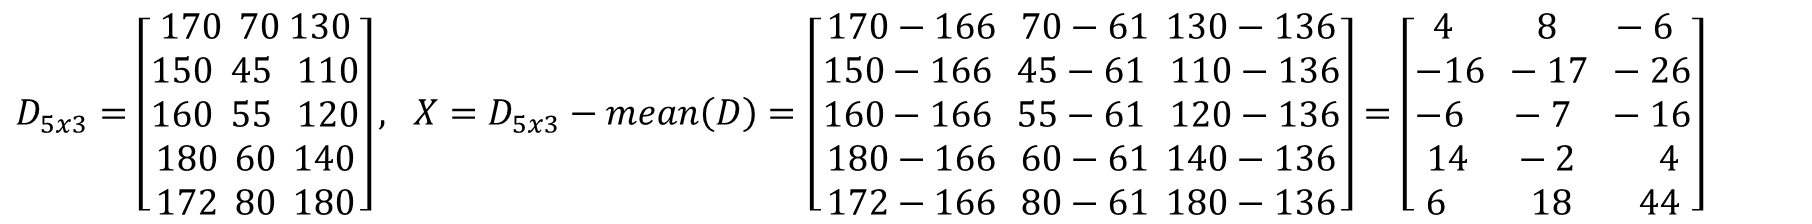

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 다변량 정규분포에서 샘플 추출

평균이 모두 0이고 공분산 행렬이 [[1,0,0],[0,1,0],[0,0,1]]인 다변량 정규분포에서 200개의 샘플을 추출합니다.

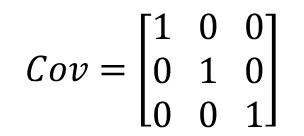

In [21]:
mean = [0, 0, 0]
cov = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
samples = np.random.multivariate_normal(mean, cov, 500)
print(samples)

[[-0.65058767 -1.39640732  1.11403476]
 [-1.3495028  -0.35841853 -0.44212505]
 [-3.23524473  0.32757384 -0.69996599]
 ...
 [ 2.83281144 -1.09511425  0.99120956]
 [ 1.25614797  0.52979635  1.68245887]
 [ 0.2378605  -1.07560655  0.72792631]]


## 선형 변환

추출된 500개의 샘플을 주어진 공분산 행렬 [[108,85.2,161.6],[85.2,146,258],[161.6,258,584]]에 의해 선형 변환합니다.


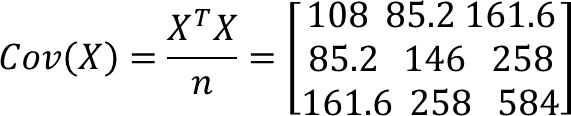

In [22]:
covariance_matrix = np.array([[108, 85.2, 161.6], [85.2, 146, 258], [161.6, 258, 584]])
transformed_samples = samples @ covariance_matrix
print(transformed_samples)

[[  -9.20935505   28.1154298   185.18824355]
 [-247.73096902 -281.37500604 -568.75266068]
 [-434.61164352 -408.40829591 -847.08163634]
 ...
 [ 372.81936698  337.20092141  754.10923673]
 [ 452.68798398  618.44846388 1322.23695294]
 [  51.68014837   51.03214722  186.04073424]]


## 3D 그래프 시각화

선형 변환된 결과를 3차원 산점도 그래프로 시각화합니다.


**Reasoning**:
Generate a 3D scatter plot of the transformed samples using matplotlib.



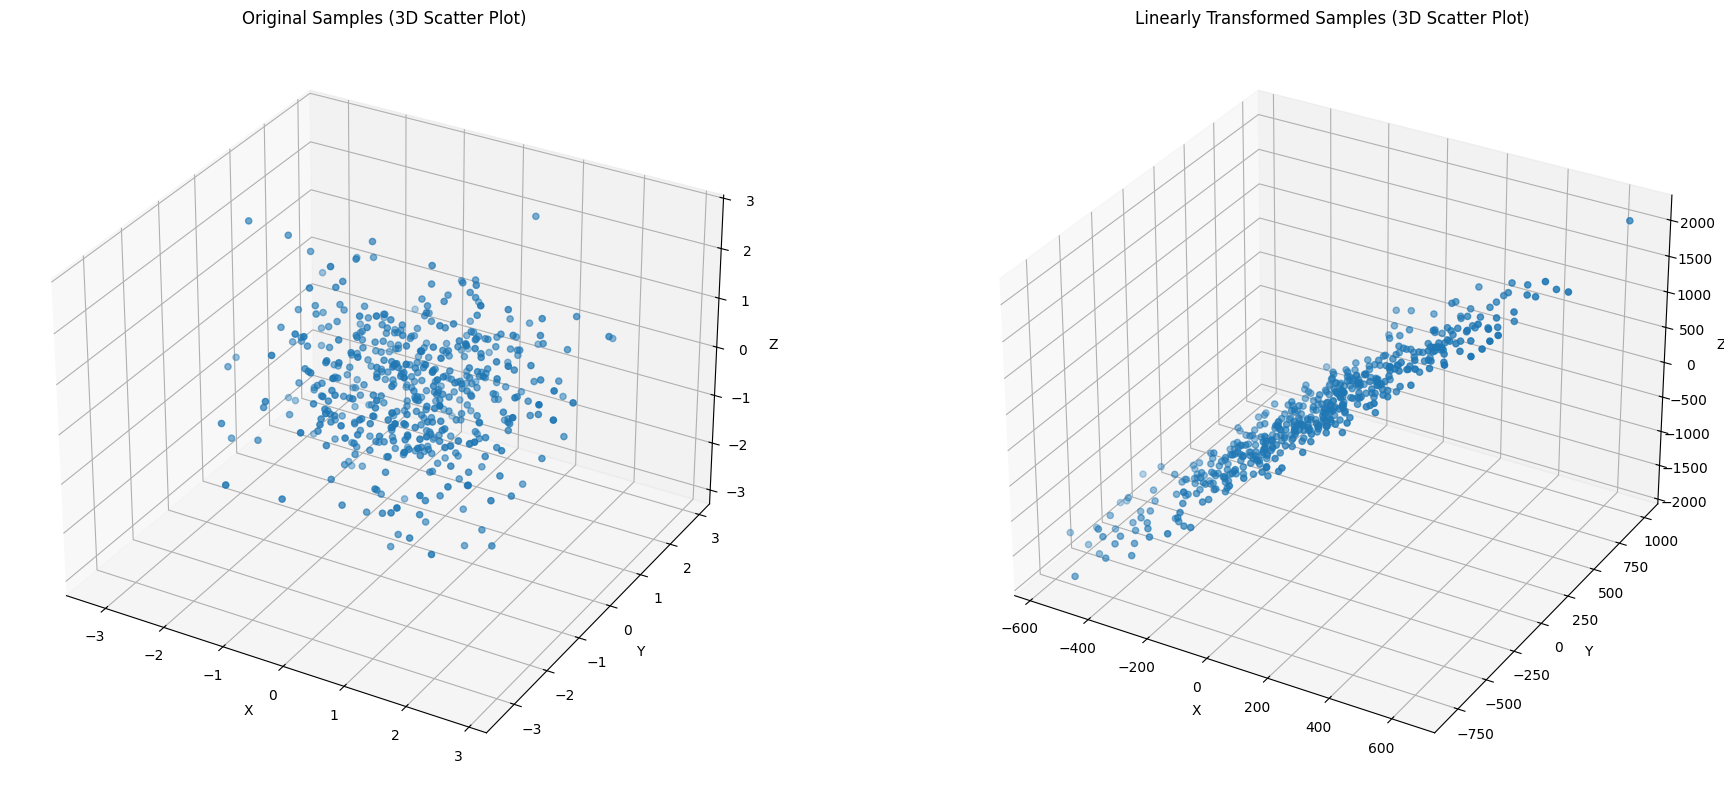

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})

# Original Samples Plot
ax1 = axes[0]
ax1.scatter(samples[:, 0], samples[:, 1], samples[:, 2])
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original Samples (3D Scatter Plot)')

# Transformed Samples Plot
ax2 = axes[1]
ax2.scatter(transformed_samples[:, 0], transformed_samples[:, 1], transformed_samples[:, 2])
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Linearly Transformed Samples (3D Scatter Plot)')

plt.tight_layout()
plt.show()

# Task
평균이 모두 0이고, 공분산 행렬 A=[[1,0,0],[0,1,0],[0,0,1]]인 다변량 정규분포를 따르는 X1, X2, X3의 샘플 200개를 추출하여 공분산 행렬 B=[[108,85.2,161.6],[85.2,146,258],[161.6,258,584]]에 의해 선형변환된 결과를 3차원 그래프로 그리고, 선형변환하기 전의 500개 샘플에 대한 3d 그래프를 추가한 후, 선형변환된 3d 그래프에 PCA를 통해 산출된 제1 주성분과 제2 주성분을 기준으로 3d에 2차원 평면을 그려줘.

## PCA 수행

선형 변환된 샘플에 대해 주성분 분석(PCA)을 수행하여 주성분과 설명된 분산을 계산합니다.


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(transformed_samples)

principal_components = pca.components_
explained_variance_ratio = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

print("Principal Components:\n", principal_components)
#print("\nExplained Variance Ratio:\n", explained_variance_ratio)
#print("\nEigenvalues:\n", eigenvalues)

Principal Components:
 [[ 0.27349325  0.40591564  0.87202863]
 [ 0.92600782  0.13414648 -0.35286575]
 [-0.2602133   0.90401173 -0.3391929 ]]

Explained Variance Ratio:
 [0.99240655 0.00638745 0.00120599]

Eigenvalues:
 [525091.53180762   3379.66147309    638.10156078]


In [26]:
matrix = np.array([[108, 85.2, 161.6], [85.2, 146, 258], [161.6, 258, 584]])
eigenvalues, eigenvectors = np.linalg.eig(matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [754.87908326  59.08510185  24.03581489]

Eigenvectors:
 [[ 0.27148847  0.92665817  0.2599974 ]
 [ 0.4074547   0.13407751 -0.90332933]
 [ 0.87193731 -0.35118066  0.34117073]]


### 고유값(Eigen Value) 고유벡터(Eigen Vector)
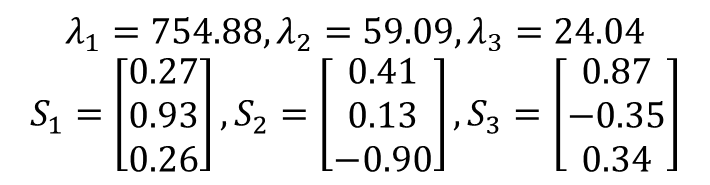

## 주성분 기준 평면 정의

계산된 제1 주성분과 제2 주성분을 사용하여 3차원 공간에서 2차원 평면을 정의합니다.


In [27]:
pc1 = principal_components[0]
pc2 = principal_components[1]
normal_vector = np.cross(pc1, pc2)
print("Normal vector of the plane:", normal_vector)

Normal vector of the plane: [-0.2602133   0.90401173 -0.3391929 ]


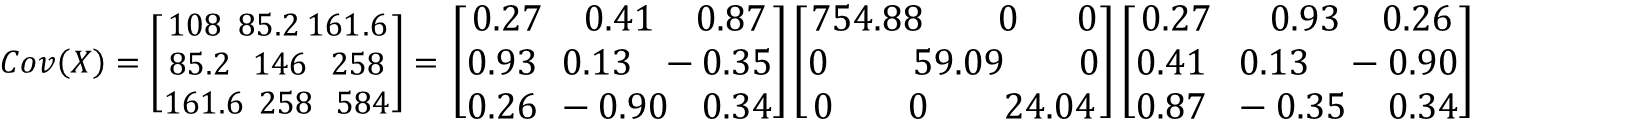

## 3d 그래프에 평면 추가

### Subtask:
선형 변환된 샘플의 3D 산점도 그래프에 정의된 2차원 평면을 추가하여 시각화합니다.


In [28]:
transformed_samples_mean = np.mean(transformed_samples, axis=0)

x_min, x_max = transformed_samples[:, 0].min(), transformed_samples[:, 0].max()
y_min, y_max = transformed_samples[:, 1].min(), transformed_samples[:, 1].max()

print("Mean of transformed samples:", transformed_samples_mean)
print("X range for plane:", x_min, x_max)
print("Y range for plane:", y_min, y_max)

Mean of transformed samples: [ -6.50134746  -9.55762581 -24.30667816]
X range for plane: -565.4044882686951 646.9264663146183
Y range for plane: -817.5022875788234 1003.4022880438076


### 제1주성분 Z1,   제2주성분:Z2
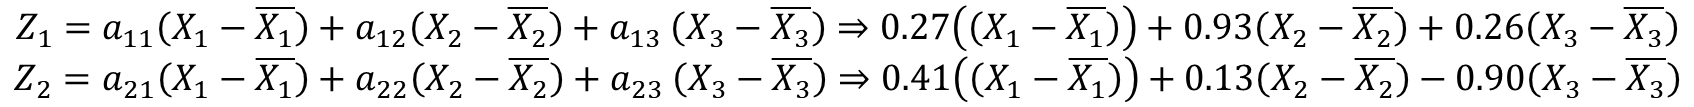

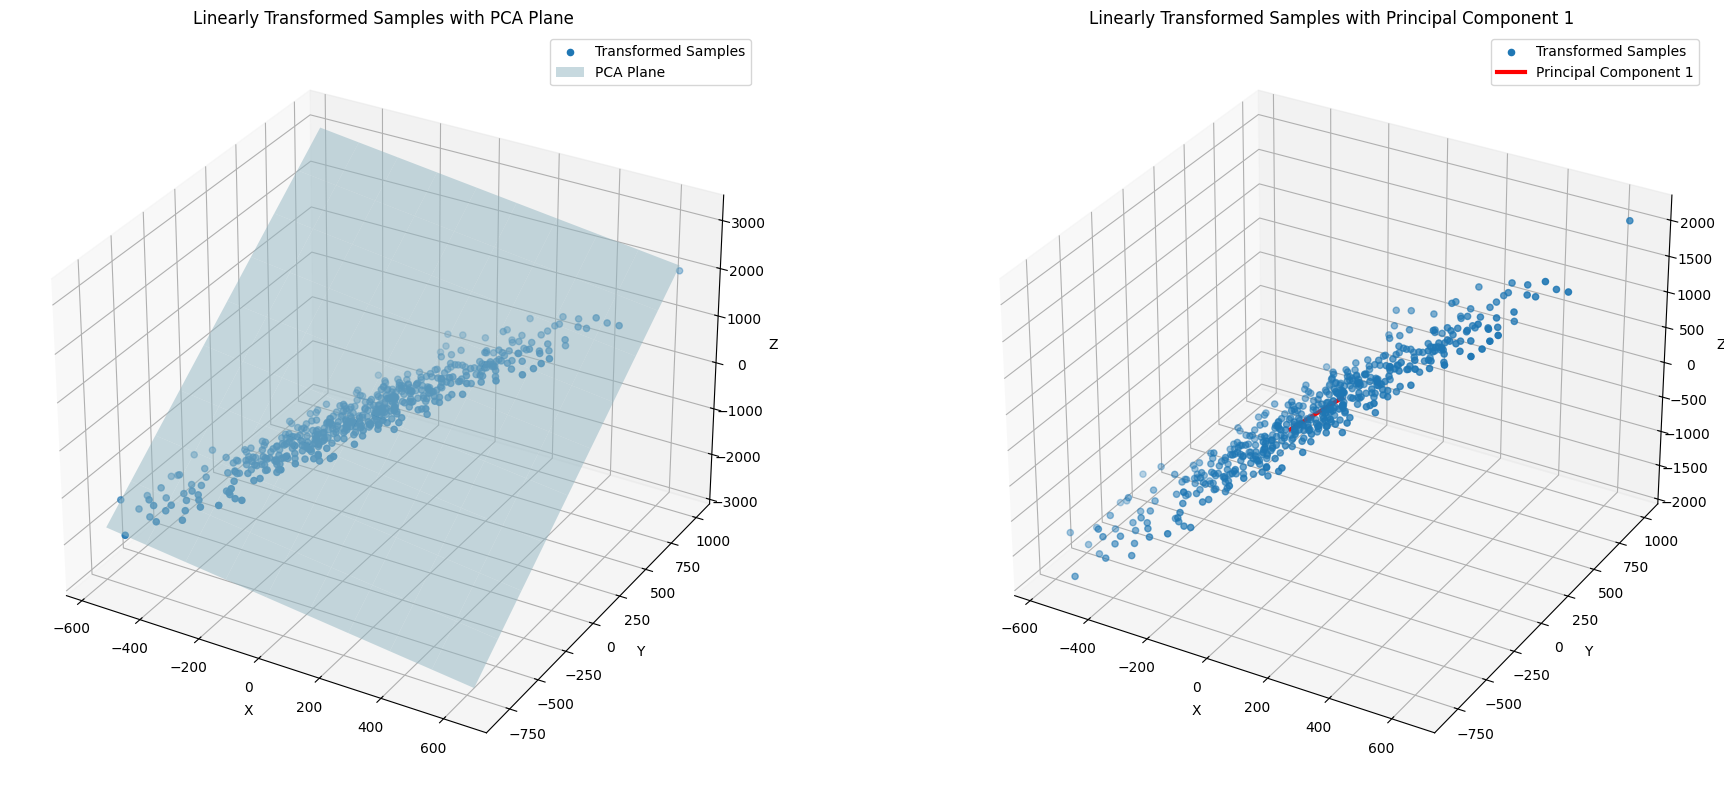

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})

# PCA Plane Plot
ax1 = axes[0]
ax1.scatter(transformed_samples[:, 0], transformed_samples[:, 1], transformed_samples[:, 2], label='Transformed Samples')

# Calculate the plane based on the first two principal components and the mean of the transformed samples
x_range = np.linspace(transformed_samples[:, 0].min(), transformed_samples[:, 0].max(), 10)
y_range = np.linspace(transformed_samples[:, 1].min(), transformed_samples[:, 1].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)
zz = (-normal_vector[0] * (xx - transformed_samples_mean[0]) - normal_vector[1] * (yy - transformed_samples_mean[1])) / normal_vector[2] + transformed_samples_mean[2]

ax1.plot_surface(xx, yy, zz, alpha=0.5, color='lightblue', label='PCA Plane')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Linearly Transformed Samples with PCA Plane')
ax1.legend()

# Principal Component 1 Plot
ax2 = axes[1]
ax2.scatter(transformed_samples[:, 0], transformed_samples[:, 1], transformed_samples[:, 2], label='Transformed Samples')
line_points = np.array([transformed_samples_mean + t * pc1 for t in np.linspace(-200, 200, 200)])
ax2.plot(line_points[:, 0], line_points[:, 1], line_points[:, 2], color='red', linewidth=3, label='Principal Component 1')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Linearly Transformed Samples with Principal Component 1')
ax2.legend()

plt.tight_layout()
plt.show()

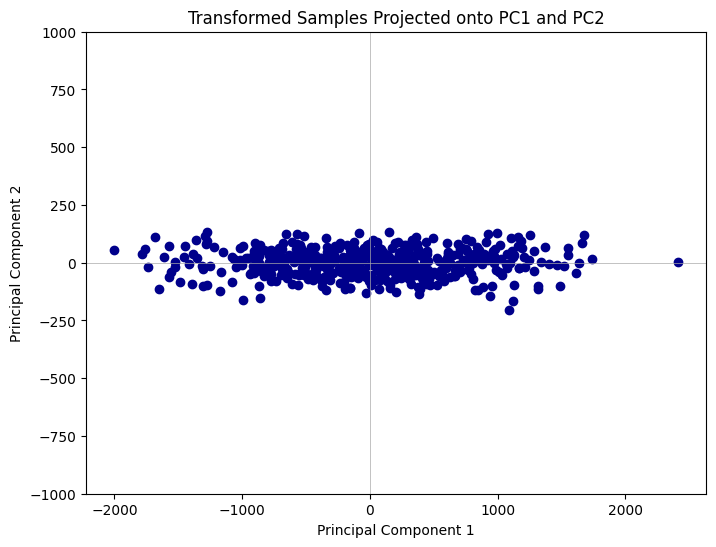

In [53]:
# Project the transformed samples onto the first two principal components
transformed_samples_pca = pca.transform(transformed_samples)[:, :2]

# Visualize the 2D projected data
plt.figure(figsize=(8, 6))
plt.scatter(transformed_samples_pca[:, 0], transformed_samples_pca[:, 1], color='darkblue')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Transformed Samples Projected onto PC1 and PC2')
plt.grid(False) # Remove grid
plt.axhline(0, color='darkgray', linewidth=0.5) # Add horizontal line at y=0
plt.axvline(0, color='darkgray', linewidth=0.5) # Add vertical line at x=0
plt.ylim(-1000, 1000)
plt.show()